<a href="https://colab.research.google.com/github/Dorokhovay/Big-Data/blob/Lab3/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Початок датасету (5 рядків):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness  mean concavity  mean concave points  mean symmetry  mean fractal dimension  radius error  texture error  perimeter error  area error  smoothness error  compactness error  concavity error  concave points error  symmetry error  fractal dimension error  worst radius  worst texture  worst perimeter  worst area  worst smoothness  worst compactness  worst concavity  worst concave points  worst symmetry  worst fractal dimension  target
0        17.99         10.38          122.80     1001.0          0.11840           0.27760          0.3001              0.14710         0.2419                 0.07871        1.0950         0.9053            8.589      153.40          0.006399            0.04904          0.05373               0.01587         0.03003                 0.006193         25.38          17.33           184.60      2019.0            0.1622             0.6656          

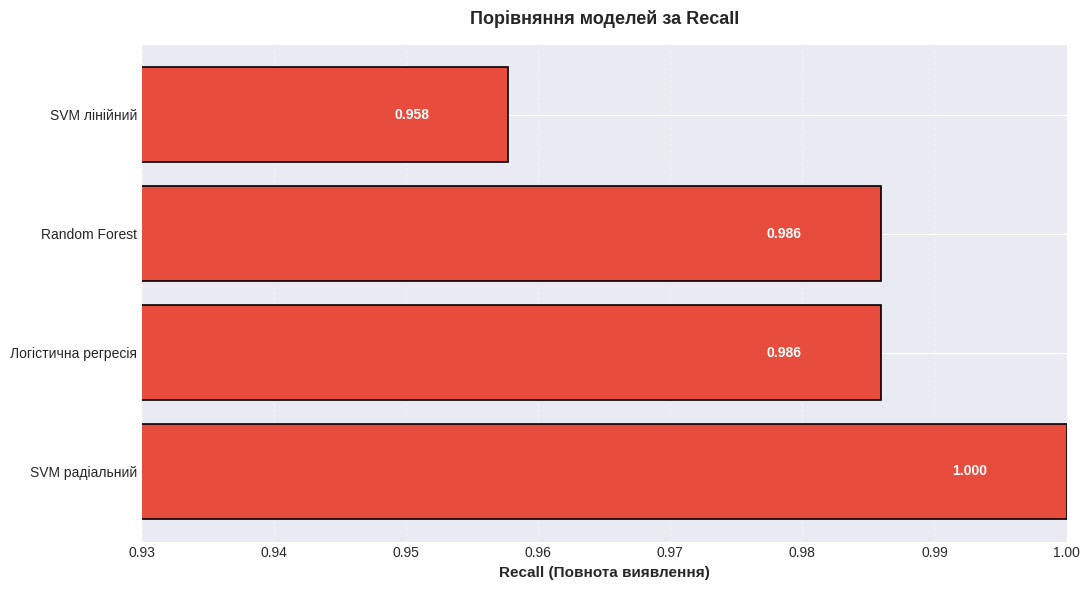

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Початок датасету (5 рядків):")
print(df.head().to_string())

print("\n\nОсновні статистичні показники (10 ознак):")
stats_df = df.iloc[:, :10].describe().loc[['mean', 'std', 'min', 'max']].T
print(stats_df.to_string())

print("\n\nБаланс цільових класів:")
class_dist = df['target'].value_counts().sort_index()
print(f"Клас 0 (злоякісна): {class_dist[0]} зразків")
print(f"Клас 1 (доброякісна): {class_dist[1]} зразків")
difference = abs(class_dist[0] - class_dist[1])
print(f"Різниця: {difference} зразків - {'дисбаланс присутній' if difference > 50 else 'баланс задовільний'}")

print("\n\nРозділення датасету\n")

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Навчальна вибірка: {X_train.shape[0]} записів")
print(f"Тестова вибірка: {X_test.shape[0]} записів")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Стандартизація ознак завершена")

print("\n\nПроцес навчання\n")

results = {}

print("Модель 1: Логістична регресія")
model_lr = LogisticRegression(random_state=42, max_iter=10000)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"  Точність: {acc_lr:.3f}")
print(f"  Precision: {prec_lr:.3f}")
print(f"  Recall: {rec_lr:.3f}")
print(f"  F1: {f1_lr:.3f}")

results['Логістична регресія'] = {
    'Accuracy': acc_lr,
    'Precision': prec_lr,
    'Recall': rec_lr,
    'F1-score': f1_lr
}

print("\n\nМодель 2: SVM (linear kernel)")
model_svm_linear = SVC(kernel='linear', random_state=42)
model_svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_linear = model_svm_linear.predict(X_test_scaled)

acc_svm_l = accuracy_score(y_test, y_pred_svm_linear)
prec_svm_l = precision_score(y_test, y_pred_svm_linear)
rec_svm_l = recall_score(y_test, y_pred_svm_linear)
f1_svm_l = f1_score(y_test, y_pred_svm_linear)

print(f"  Точність: {acc_svm_l:.3f}")
print(f"  Precision: {prec_svm_l:.3f}")
print(f"  Recall: {rec_svm_l:.3f}")
print(f"  F1: {f1_svm_l:.3f}")

results['SVM лінійний'] = {
    'Accuracy': acc_svm_l,
    'Precision': prec_svm_l,
    'Recall': rec_svm_l,
    'F1-score': f1_svm_l
}

print("\n\nМодель 3: SVM (RBF kernel)")
model_svm_rbf = SVC(kernel='rbf', random_state=42)
model_svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm_rbf = model_svm_rbf.predict(X_test_scaled)

acc_svm_r = accuracy_score(y_test, y_pred_svm_rbf)
prec_svm_r = precision_score(y_test, y_pred_svm_rbf)
rec_svm_r = recall_score(y_test, y_pred_svm_rbf)
f1_svm_r = f1_score(y_test, y_pred_svm_rbf)

print(f"  Точність: {acc_svm_r:.3f}")
print(f"  Precision: {prec_svm_r:.3f}")
print(f"  Recall: {rec_svm_r:.3f}")
print(f"  F1: {f1_svm_r:.3f}")

results['SVM радіальний'] = {
    'Accuracy': acc_svm_r,
    'Precision': prec_svm_r,
    'Recall': rec_svm_r,
    'F1-score': f1_svm_r
}

print("\n\nМодель 4: Random Forest")
model_rf = RandomForestClassifier(random_state=42, n_estimators=100)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"  Точність: {acc_rf:.3f}")
print(f"  Precision: {prec_rf:.3f}")
print(f"  Recall: {rec_rf:.3f}")
print(f"  F1: {f1_rf:.3f}")

results['Random Forest'] = {
    'Accuracy': acc_rf,
    'Precision': prec_rf,
    'Recall': rec_rf,
    'F1-score': f1_rf
}

print("\n\nЗведені результати\n")

comparison = pd.DataFrame(results).T
comparison_sorted = comparison.sort_values(by='Recall', ascending=False)

print(comparison_sorted.round(3).to_string())

best_model = comparison_sorted.index[0]
best_recall = comparison_sorted['Recall'].iloc[0]

print(f"\nЛідер за Recall: {best_model}")
print(f"Показник Recall: {best_recall:.3f}")
print(f"\nПримітка: У медичній діагностіці Recall критично важливий,")
print(f"оскільки пропуск хворого (False Negative) може коштувати життя.")

# Графік
fig, ax = plt.subplots(figsize=(11, 6))

y_pos = np.arange(len(comparison_sorted))
bars = ax.barh(y_pos, comparison_sorted['Recall'], color='#e74c3c', edgecolor='black', linewidth=1.2)

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_sorted.index)
ax.set_xlabel('Recall (Повнота виявлення)', fontsize=11, weight='bold')
ax.set_title('Порівняння моделей за Recall', fontsize=13, weight='bold', pad=15)
ax.set_xlim([0.93, 1.0])
ax.grid(axis='x', alpha=0.4, linestyle='--')

for i, (bar, val) in enumerate(zip(bars, comparison_sorted['Recall'])):
    ax.text(val - 0.006, i, f'{val:.3f}', va='center', ha='right',
            fontsize=10, weight='bold', color='white')

plt.tight_layout()
plt.show()
